In [1]:
# This notebook is for training the ATPC data with a 3D CNN
# Loads in preprocessed image files that have been pre-shuffled and voxelized

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import json
import time
from tqdm import tqdm
import lmdb
import pickle

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

import spconv.pytorch as spconv

from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

%matplotlib widget

In [2]:
# Check for CUDA (NVIDIA) or MPS (Apple)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

NVIDIA GeForce RTX 2060
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB
Using device: cuda


In [3]:
# SpCov expects batch index to be ordered from 0 to batch_size -1
# When we run in batches, we get random indexes
# to fix this during training we shift the set so the batch index goes back from 0 to 1 
# i.e. we are using local batch index during training
def spconv_collate_fn(batch):
    coords_list, feats_list, labels_list, meta_list = zip(*batch)
    
    # Update the batch index (first column of coords)
    # Without this, spconv thinks every point in the batch belongs to 'Event 0'
    new_coords_list = []
    for i, coords in enumerate(coords_list):
        # Set the first column to the actual index in this specific batch
        coords[:, 0] = i 
        new_coords_list.append(coords)
        
    # Concatenate everything into single large tensors
    batch_coords = torch.cat(new_coords_list, dim=0)
    batch_feats  = torch.cat(feats_list, dim=0)
    batch_labels = torch.stack(labels_list, dim=0)
    
    # Structure meta list like 
    #{"event_id": [101, 102, 103, 104],"subType": ["TypeA", "TypeB", "TypeA", "TypeC"]}
    batch_meta = {
        key: [m[key] for m in meta_list] 
        for key in meta_list[0].keys()
    }
    
    return batch_coords, batch_feats, batch_labels, batch_meta


In [4]:
def GetSpatialShape(df, max_x, max_y, max_z):
        
    if (max(df['z']) > max_z): max_z = max(df['z'])
    if (max(df['y']) > max_y): max_y = max(df['y'])
    if (max(df['x']) > max_x): max_x = max(df['x'])

    # Convert to voxel units and add a buffer
    global_max_coords = np.array([max_z, max_y, max_x])
    spatial_shape = np.ceil(global_max_coords).astype(int) + 1

    # Round up to a multiple of 8 or 16
    # This ensures that stride-2 layers divide cleanly
    input_data_shape = [ int(((s + 15) // 16) * 16) for s in spatial_shape]
    return input_data_shape, max_x, max_y, max_z

def MakeLMBD(file_paths, data_sample):

    lmdb_path = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_{data_sample}_events.lmdb"
    meta_file = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_{data_sample}_meta.json"
    
    # lmdb_path = f"CNN_{data_sample}_events_test.lmdb"
    # meta_file = f"CNN_{data_sample}_meta_test.json"
    
    subtype_counts = Counter()
    max_z = 0
    max_y = 0
    max_x = 0
    input_data_shape = [0, 0, 0]
    
    # If we have the file already then we dont need to run again. 
    if os.path.exists(lmdb_path):
        print("CNN LMDB files exist, so returning...")
        return
    
    env = lmdb.open(lmdb_path, map_size=1e12)  # adjust if needed

    mapping = {"Bi": 0, "Tl": 1, "single": 2, "0nubb": 3}

    idx = 0

    with env.begin(write=True) as txn:
        for file_path in file_paths:
            shard = torch.load(file_path, map_location="cpu")

            for df in tqdm(shard):
                coords = df[['z', 'y', 'x']].values.astype(np.int16)
                energy = df[['energy']].values.astype(np.float32)

                label = int(df.label.iloc[0])
                subtype = int(mapping[df.subType.iloc[0]])
                subtype_counts.update([subtype])
                event_id = df.event_id.iloc[0]

                event = {
                    "coords": coords,
                    "energy": energy,
                    "label": label,
                    "subtype": subtype,
                    "event_id": event_id
                }

                key = f"{idx:09d}".encode()
                value = pickle.dumps(event)

                txn.put(key, value)
                idx += 1
                
                input_data_shape, max_x, max_y, max_z = GetSpatialShape(df, max_x, max_y, max_z)
        
        # Save the metadata too
        print(f"Saving metadata to {meta_file}...")
        print(dict(subtype_counts))
        print(input_data_shape)
        with open(meta_file, 'w') as f:
            json.dump({
                'subtype_counts': dict(subtype_counts),
                'input_data_shape': input_data_shape
            }, f)

    env.close()
    print(f"Stored {idx} events")

MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/ATPC_CNN_chunk_train_*.pt")), "Train")
MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/ATPC_CNN_chunk_val_*.pt")),   "Validation")
MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/ATPC_CNN_chunk_test_*.pt")),  "Test")

CNN LMDB files exist, so returning...
CNN LMDB files exist, so returning...
CNN LMDB files exist, so returning...


In [5]:
class LMDBEventDataset(Dataset):
    def __init__(self, lmdb_path, data_sample):
        self.env = lmdb.open(lmdb_path, readonly=True, lock=False)
        
        # Load in the metadata
        meta_file = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_{data_sample}_meta.json"
        # meta_file = f"CNN_{data_sample}_meta_test.json"
        
        print(f"Loading metadata from cache: {meta_file}")
        with open(meta_file, 'r') as f:
            cache_data = json.load(f)
            raw_counts = cache_data['subtype_counts']
            self.subtype_counts = Counter({int(k): v for k, v in raw_counts.items()})
            self.input_data_shape = cache_data["input_data_shape"]
            
        self.print_scale_factors(data_sample)
        print("The input shape is: ")
        print(self.input_data_shape)
        
        with self.env.begin() as txn:
            self.length = txn.stat()['entries']

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        with self.env.begin() as txn:
            key = f"{idx:09d}".encode()
            data = pickle.loads(txn.get(key))

        coords = data["coords"]
        energy = data["energy"]
        # energy = np.ones_like(data["energy"]) # set all energies to 1 for now, since we are just testing the pipeline
        label  = data["label"]
        subtype = data["subtype"]
        event_id = data["event_id"]

        batch_indices = np.zeros((coords.shape[0], 1), dtype=np.int32)
        spconv_coords = np.hstack([batch_indices, coords])

        return (
            torch.from_numpy(spconv_coords).int(),
            torch.from_numpy(energy).float(),
            torch.tensor(label),
            {"subType": subtype, "event_id": event_id}
        )
        
    def print_scale_factors(self, data_sample):
        sig = self.subtype_counts[0]
        bi  = self.subtype_counts[1]
        tl  = self.subtype_counts[2]
        sn  = self.subtype_counts[3]
        total_bkg = bi + tl + sn

        print(f"\n--- {data_sample} Dataset Summary ---")
        print(f"Signal (0nubb): {sig}")
        print(f"Background: {total_bkg}")
        print(f"Thalium: {tl}")
        print(f"Bismuth: {bi}")
        print(f"Single: {sn}")

train_dataset = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_Train_events.lmdb", "Train")
val_dataset   = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_Validation_events.lmdb", "Validation")
test_dataset  = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_Test_events.lmdb", "Test")

# train_dataset = LMDBEventDataset("CNN_Train_events_test.lmdb", "Train")
# val_dataset   = LMDBEventDataset("CNN_Validation_events_test.lmdb", "Validation")
# test_dataset  = LMDBEventDataset("CNN_Test_events_test.lmdb", "Test")


Loading metadata from cache: /media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_Train_meta.json

--- Train Dataset Summary ---
Signal (0nubb): 589105
Background: 1628062
Thalium: 553553
Bismuth: 531420
Single: 543089
The input shape is: 
[784, 784, 784]
Loading metadata from cache: /media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_Validation_meta.json

--- Validation Dataset Summary ---
Signal (0nubb): 167592
Background: 465932
Thalium: 158277
Bismuth: 152475
Single: 155180
The input shape is: 
[784, 784, 784]
Loading metadata from cache: /media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/CNN_Test_meta.json

--- Test Dataset Summary ---
Signal (0nubb): 84031
Background: 232763
Thalium: 79060
Bismuth: 76107
Single: 77596
The input shape is: 
[784, 784, 784]


In [6]:
BATCH_SIZE = 200
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=5, pin_memory=True, persistent_workers=True, prefetch_factor=4, collate_fn=spconv_collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=5, pin_memory=True, persistent_workers=True, prefetch_factor=4, collate_fn=spconv_collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=5, pin_memory=True, persistent_workers=True, prefetch_factor=4, collate_fn=spconv_collate_fn)

{'subType': 0, 'event_id': 31500000113}
tensor(331, dtype=torch.int32)


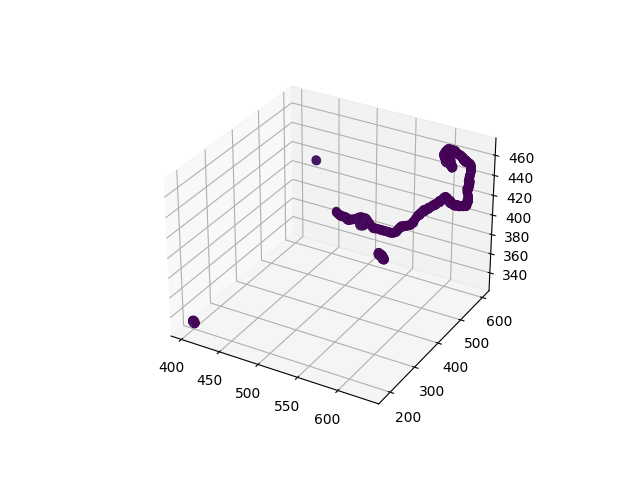

In [7]:
# This is how you can plot an event loaded in
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Get df 0, coords, x
# train_dataset[0][0][:,1]

eid = 0

print(train_dataset[eid][3])

print(min(train_dataset[eid][0][:,3]))


ax.scatter(train_dataset[eid][0][:,1], train_dataset[eid][0][:,2], train_dataset[eid][0][:,3], c = train_dataset[eid][1][:,0]);

In [8]:

class SparseEventNet(nn.Module):
    def __init__(self, input_channels, num_classes, spatial_shape):
        super(SparseEventNet, self).__init__()
        self.spatial_shape = spatial_shape
        
        self.net = spconv.SparseSequential(
            # Block 1
            spconv.SubMConv3d(input_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Block 2 
            spconv.SubMConv3d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Block 3: Downsample (Stride 2)
            spconv.SparseConv3d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Block 4
            spconv.SubMConv3d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            # Block 5: Final Downsample to a small feature map
            spconv.SparseConv3d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        # Final Dense Layer to cast to number of classes
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, features, coords, batch_size):
        
        x = spconv.SparseConvTensor(features, coords, self.spatial_shape, batch_size)
        x = self.net(x)
        out = self.global_pool(x)
        
        return self.fc(out)

    # Global Pooling
    # Take the features of the remaining sparse points and average+get max (per image)
    # x.features is a tensor of [Total_Active_Points, features]
    # We need to average these per-image using the batch indices in x.indices
    def global_pool(self, x):
        features = x.features
        batch_ids = x.indices[:, 0]
        pooled_feats = []
        for i in range(x.batch_size):
            mask = (batch_ids == i)
            if mask.any():
                pooled_feats.append(torch.cat([
                    features[mask].mean(dim=0),
                    features[mask].max(dim=0)[0]
                ]))
            # Safetey block in case a processed image is empty at this stage (no active voxels)
            # In this case return array of zeros. 
            else:
                pooled_feats.append(torch.zeros(features.shape[1]).to(features.device))
        return torch.stack(pooled_feats)

In [9]:
# Dervive weights based on inverse frequency
# Total / (Num_Classes * Class_Count)
# This method boosts signal and scales background down simultaniously
# average weight will remain 1
# Grab counts from the dataset object
sig = train_dataset.subtype_counts[0]
bi  = train_dataset.subtype_counts[1]
tl  = train_dataset.subtype_counts[2]
sn  = train_dataset.subtype_counts[3]
total_bkg = bi + tl + sn

# Calculate the raw factors
sf_bkg    = sig / total_bkg if total_bkg > 0 else 1.0
sf_bi     = sig / bi if bi > 0 else 1.0
sf_tl     = sig / tl if tl > 0 else 1.0
sf_single = sig / sn if sn > 0 else 1.0

total = total_bkg + sig
weight_bkg = total / (2 * total_bkg)
weight_signal = total / (2 * sig)

print("Weight signal:", weight_signal)
print("Weight Background:", weight_bkg)

Weight signal: 1.8818096943668785
Weight Background: 0.6809221638979351


In [ ]:
# Create the model
model = SparseEventNet(input_channels=1, num_classes=2, spatial_shape=train_dataset.input_data_shape).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5) #  This will help adjust the learning rate
class_weights = torch.tensor([weight_bkg, weight_signal], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights).to(device) # can add this so it relaxes the loss criterion a bit. label_smoothing=0.1

total_batches = len(train_loader)
report_interval = max(1, total_batches // 5) # report every 20% batch processed
print("total batches", total_batches, "| report_interval", report_interval)

min_epoch = 0
last_epoch=0
history_df = pd.DataFrame()
best_val_loss=1e20

# VERSION = 1 # This is full event sample default settings
# VERSION = 2 # This changes the energy so the values are all 1. 
VERSION = 3 # This is with fix to the voxel function

load_state = True
if (load_state):
    history_df = pd.read_csv(f"../CNN_files/CNN_train_history_v{VERSION}.csv")
    print("Loading Model State from file!")
    display(history_df)
    
    last_epoch = int(max(history_df.epoch)) # Carry on from the last epoch
    checkpoint = torch.load(f'../CNN_files/CNN_v{VERSION}_epoch{last_epoch}.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    min_epoch     = checkpoint['epoch']+1
    best_val_loss = checkpoint['loss']

# ---------------------------------------------------------------------------------------------------
EPOCHS = 5

for epoch in range(min_epoch, min_epoch+EPOCHS):
    print("Running Epoch ", epoch)
    t0 = time.time()

    # ---- train ---------------------------------------------------------------------------------
    model.train()
    train_loss = 0
    i = 0
    for coords, feats, y, meta in train_loader:
        coords, feats, y = coords.to(device), feats.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(feats, coords, y.shape[0]) # array (Nbatch, [logit_bkg, logit_sig])
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
        # Print every 10%
        if (i + 1) % report_interval == 0:
            percent_done = (i + 1) / total_batches * 100
            print(f"Progress Epoch {epoch}: {percent_done:.0f}% ({i + 1}/{total_batches} batches)")
            
        i = i+1

    # ---- validate ---------------------------------------------------------------------------------
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    val_loss = 0
    with torch.no_grad():
        for coords, feats, y, meta in val_loader:
            
            coords, feats, y = coords.to(device), feats.to(device), y.to(device)
            logits = model(feats, coords, y.shape[0])
            loss = criterion(logits, y)
            val_loss += loss.item()
            probs = torch.softmax(logits, dim=1) # convert logits to probs, normalize to 1 
            preds = logits.argmax(dim=1)         # Return index with highest logit, class pred 0 or 1
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy()) # logits of signal column
            all_labels.extend(y.cpu().numpy())
    
    # Adjust the learning rate scheduler
    scheduler.step(val_loss)
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }
    
    torch.save(checkpoint, f'../CNN_files/CNN_v{VERSION}_epoch{epoch}.pt')
    
    # Just useful to print
    if val_loss < best_val_loss:
        print("Model improved! Saving...")
        best_val_loss = val_loss

    AUC  = roc_auc_score(all_labels, all_probs)
    f1   = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds)
    
    t1 = time.time()
    epoch_time = (t1 - t0)/60.
    print("Epoch time was:", epoch_time, "m")
    
    
    # Save the history of the training -----------------------------------------------------------------------------
    # Saving the information from the training
    metrics = {
        'epoch': epoch,
        'epoch_time': float(epoch_time),
        'train_loss': float(train_loss),
        'val_loss': float(val_loss),
        'val_f1': float(f1),
        'val_prec': float(prec),
        'val_rec': float(rec),
        'val_auc':float(AUC)
        
    }
    print(metrics)
    
    try:
        history_df = pd.read_csv(f"../CNN_files/CNN_train_history_v{VERSION}.csv")
    except:
        history_df = pd.DataFrame()
        
    history_df_current = pd.DataFrame([metrics])
    history_df = pd.concat( [history_df, history_df_current])
    history_df.to_csv(f'../CNN_files/CNN_train_history_v{VERSION}.csv', index=False)
    
    print(f"Epoch {epoch+1}/{min_epoch+EPOCHS} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | Val AUC: {AUC:.6f}")
    last_epoch=epoch


display(history_df)


total batches 11086 | report_interval 2217
Loading Model State from file!


,epoch,epoch_time,train_loss,val_loss,val_f1,val_prec,val_rec,val_auc
0,0,116.201026,1989.351869,374.166959,0.937437,0.927937,0.947132,0.991544
1,1,115.474091,1077.694247,285.802436,0.936221,0.895162,0.981228,0.993827
2,2,115.290633,994.791932,277.987567,0.946677,0.922541,0.972110,0.994067


Running Epoch  3


In [ ]:
model = SparseEventNet(input_channels=1, num_classes=2, spatial_shape=train_dataset.input_data_shape).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
class_weights = torch.tensor([weight_bkg, weight_signal], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights).to(device)

history_df = pd.read_csv(f"../CNN_files/CNN_train_history_v{VERSION}.csv")
print("Loading Model State from file!")
display(history_df)

last_epoch = int(max(history_df.epoch)) # Carry on from the last epoch



checkpoint = torch.load(f'../CNN_files/CNN_v{VERSION}_epoch{last_epoch}.pt', map_location=device)

# 4. Restore the states
model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']


Loading Model State from file!


,epoch,epoch_time,train_loss,val_loss,val_f1,val_prec,val_rec,val_auc
0,0,116.201026,1989.351869,374.166959,0.937437,0.927937,0.947132,0.991544
1,1,115.474091,1077.694247,285.802436,0.936221,0.895162,0.981228,0.993827
2,2,115.290633,994.791932,277.987567,0.946677,0.922541,0.972110,0.994067


In [ ]:
# Now we want to make the following plots:
# ROC curve -- train, validation, test

def CalcModelMetrics(data_loader, name ,device ):
    
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    all_subTypes = []
    all_event_ids = []
    val_loss = 0
    with torch.no_grad():
        for coords, feats, y, meta in data_loader:
            
            coords, feats, y = coords.to(device), feats.to(device), y.to(device)
            logits = model(feats, coords, y.shape[0])
            loss = criterion(logits, y)
            val_loss += loss.item()
            probs = torch.softmax(logits, dim=1) # convert logits to probs, normalize to 1 
            preds = logits.argmax(dim=1)         # Return index with highest logit, class pred 0 or 1
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
            all_subTypes.extend(meta["subType"])
            all_event_ids.extend(meta["event_id"])
        
    # df_scores = pd.DataFrame({"y_score_raw": all_preds, "y_score": all_probs, "y_true": all_labels, "subTypes" : all_subTypes})
    df_scores = pd.DataFrame({"event_id": all_event_ids, "y_score_raw": all_preds, "y_score": all_probs, "y_true": all_labels, "subTypes" : all_subTypes})

    fpr, tpr, _  = roc_curve(all_labels, all_probs)
    f1   = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds)
    AUC  = auc(fpr, tpr)
    
    print(name, "|| F1:", round(f1,5), "| Precision",  round(prec,5), "| Recall", round(rec,5), "| AUC", round(AUC,5))
    
    return fpr, tpr, AUC, df_scores

fpr_train, tpr_train, AUC_train, df_scores_train = CalcModelMetrics(train_loader, "Train     ", device)
fpr_val,   tpr_val,   AUC_val,   df_scores_val   = CalcModelMetrics(val_loader,   "Validation", device)
fpr_test,  tpr_test,  AUC_test,  df_scores_test  = CalcModelMetrics(test_loader,  "Test      ", device)
df_scores_all = pd.concat([df_scores_train, df_scores_val, df_scores_test])


Train      || F1: 0.94898 | Precision 0.92393 | Recall 0.97542 | AUC 0.99476
Validation || F1: 0.94668 | Precision 0.92254 | Recall 0.97211 | AUC 0.99407
Test       || F1: 0.94662 | Precision 0.92155 | Recall 0.97309 | AUC 0.99412


Confusion Matrix:
True Bkg: 2328912 | False Signal: 62708
False Bkg: 19766 | True Signal: 756099


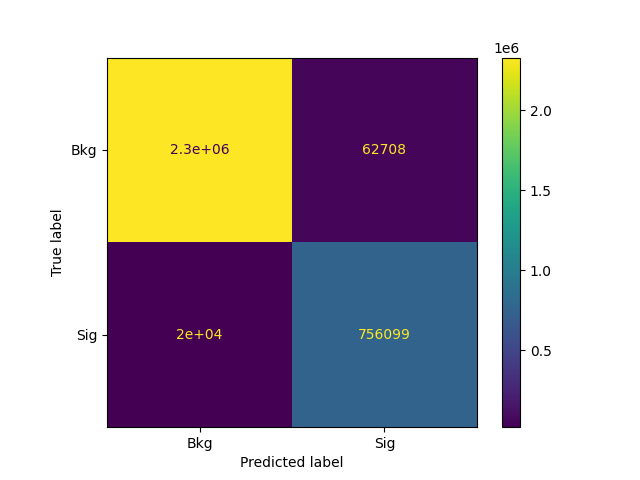

In [ ]:
cm = confusion_matrix(df_scores_all.y_true, df_scores_all.y_score_raw)
print("Confusion Matrix:")
print(f"True Bkg: {cm[0,0]} | False Signal: {cm[0,1]}")
print(f"False Bkg: {cm[1,0]} | True Signal: {cm[1,1]}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bkg", "Sig"])
disp.plot()
plt.show()


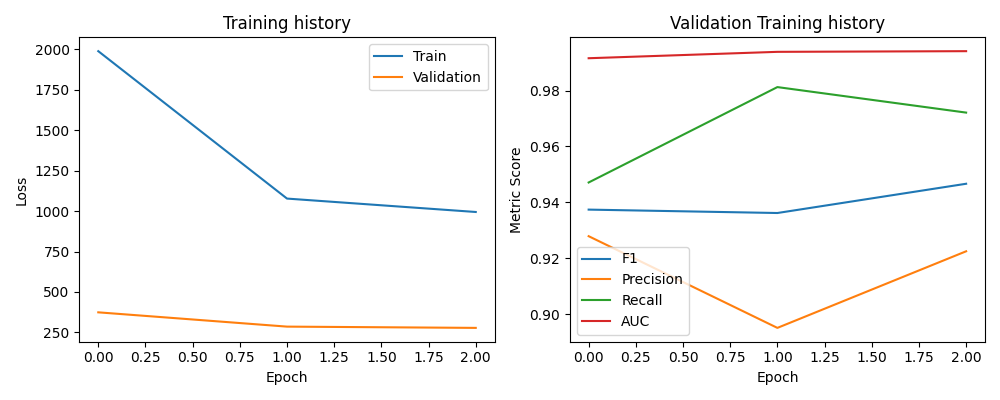

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

axs[0].plot(history_df.train_loss, label='Train')
axs[0].plot(history_df.val_loss, label='Validation')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training history')
plt.tight_layout()

axs[1].plot(history_df.val_f1, label='F1')
axs[1].plot(history_df.val_prec, label='Precision')
axs[1].plot(history_df.val_rec, label='Recall')
axs[1].plot(history_df.val_auc, label='AUC')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Metric Score')
axs[1].legend()
axs[1].set_title('Validation Training history')
plt.tight_layout()

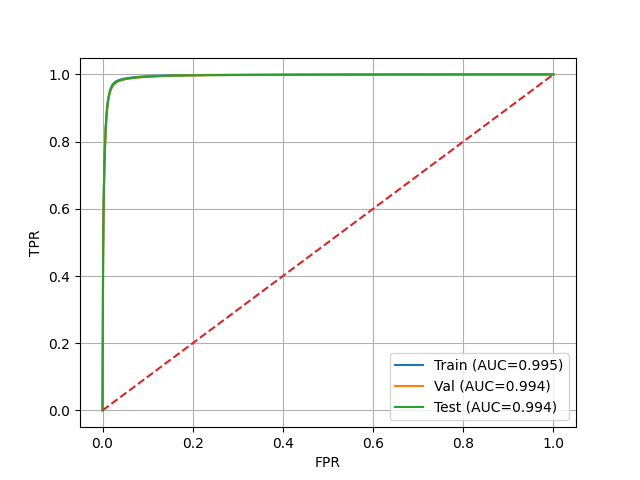

In [ ]:
plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train (AUC={AUC_train:.3f})")
plt.plot(fpr_val, tpr_val, label=f"Val (AUC={AUC_val:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test (AUC={AUC_test:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()


Cut =  0.97
Signal Eff:   0.60
Bkg Eff, Bkg Rej, Bkg Rej Fact
Tl ERej:      0.001 0.999 910.18
Bi ERej:      0.002 0.998 404.59
single ERej:  0.003 0.997 294.34


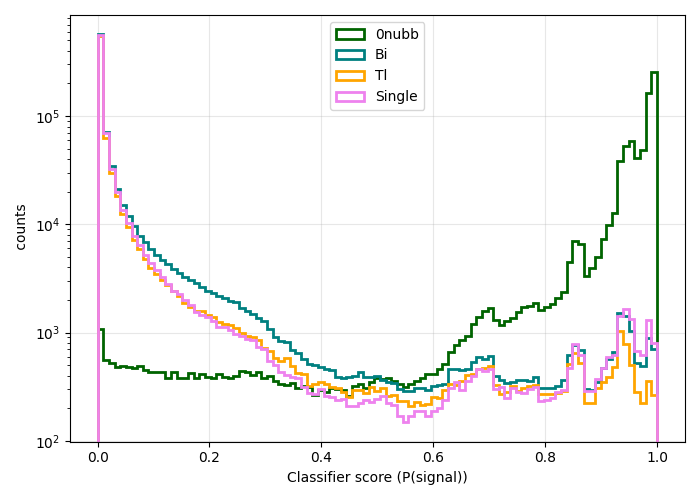

In [ ]:
mapping = {"Bi": 0, "Tl": 1, "single": 2, "0nubb": 3}

def CalcEfficiency(df, label, cut):
    num = len(df[ (df.subTypes == label) & (df.y_score > cut)])
    den = len(df[ (df.subTypes == label)])
    return num/den

# 0.58 eff needed
cut = 0.97

print("Cut = ", cut)
print(f"Signal Eff:   {CalcEfficiency(df_scores_all, mapping['0nubb'], cut):.2f}")

print("Bkg Eff, Bkg Rej, Bkg Rej Fact")
tl_eff = CalcEfficiency(df_scores_all, mapping["Tl"], cut)
print(f"Tl ERej:      {tl_eff:.3f} {1-tl_eff:.3f} {1/tl_eff:.2f}")

bi_eff = CalcEfficiency(df_scores_all, mapping["Bi"], cut)
print(f"Bi ERej:      {bi_eff:.3f} {1-bi_eff:.3f} {1/bi_eff:.2f}")

s_eff = CalcEfficiency(df_scores_all, mapping["single"], cut)
print(f"single ERej:  {s_eff:.3f} {1-s_eff:.3f} {1/s_eff:.2f}")

plt.figure(figsize=(7,5))

bins = np.linspace(0,1,100)

plt.hist(df_scores_all[ (df_scores_all.subTypes == mapping["0nubb"])].y_score,  bins=bins, density=False, histtype='step', linewidth=2, label='0nubb',  color = "darkgreen");
plt.hist(df_scores_all[ (df_scores_all.subTypes == mapping["Bi"])].y_score,     bins=bins, density=False, histtype='step', linewidth=2, label='Bi',     color = "Teal");
plt.hist(df_scores_all[ (df_scores_all.subTypes == mapping["Tl"])].y_score,     bins=bins, density=False, histtype='step', linewidth=2, label='Tl',     color = "Orange");
plt.hist(df_scores_all[ (df_scores_all.subTypes == mapping["single"])].y_score, bins=bins, density=False, histtype='step', linewidth=2, label='Single', color = "violet");


plt.xlabel("Classifier score (P(signal))")
plt.ylabel(" counts")
plt.legend()
plt.grid(alpha=0.3)

plt.semilogy()
plt.tight_layout()
plt.show()